In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [5]:
df=pd.read_csv('algerian forest fires cleaned data.csv')

In [6]:
df


,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,1,6,2012,32,71,12,0.7,57.1,2.5,8.2,0.6,2.8,0.2,not fire,0
2,1,7,2012,28,58,18,2.2,63.7,3.2,8.5,1.2,3.3,0.5,not fire,0
3,1,7,2012,29,68,19,1.0,59.9,2.5,8.6,1.1,2.9,0.4,not fire,0
4,1,8,2012,36,45,14,0.0,78.8,4.8,10.2,2.0,4.7,0.9,not fire,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
238,9,7,2012,36,43,15,1.9,82.3,9.4,9.9,3.2,9.0,3.1,fire,1
239,9,8,2012,35,59,17,0.0,87.4,14.8,57.0,6.9,17.9,9.9,fire,1
240,9,8,2012,39,43,12,0.0,91.7,16.5,30.9,9.6,16.4,12.7,fire,1
241,9,9,2012,30,77,15,1.0,56.1,2.1,8.4,0.7,2.6,0.2,not fire,1


In [7]:
df.drop(['day','month','year'],axis=1,inplace=True)

In [8]:
df

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,32,71,12,0.7,57.1,2.5,8.2,0.6,2.8,0.2,not fire,0
2,28,58,18,2.2,63.7,3.2,8.5,1.2,3.3,0.5,not fire,0
3,29,68,19,1.0,59.9,2.5,8.6,1.1,2.9,0.4,not fire,0
4,36,45,14,0.0,78.8,4.8,10.2,2.0,4.7,0.9,not fire,0
...,...,...,...,...,...,...,...,...,...,...,...,...
238,36,43,15,1.9,82.3,9.4,9.9,3.2,9.0,3.1,fire,1
239,35,59,17,0.0,87.4,14.8,57.0,6.9,17.9,9.9,fire,1
240,39,43,12,0.0,91.7,16.5,30.9,9.6,16.4,12.7,fire,1
241,30,77,15,1.0,56.1,2.1,8.4,0.7,2.6,0.2,not fire,1


In [10]:
df['Classes'].value_counts()

Classes
fire             131
not fire         101
fire               4
not fire           2
fire               2
not fire           1
not fire           1
not fire           1
Name: count, dtype: int64

In [11]:
#encoding 
df['Classes']=np.where(df['Classes'].str.contains("not fire"),0,1)

In [12]:
df.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0,0
1,32,71,12,0.7,57.1,2.5,8.2,0.6,2.8,0.2,0,0
2,28,58,18,2.2,63.7,3.2,8.5,1.2,3.3,0.5,0,0
3,29,68,19,1.0,59.9,2.5,8.6,1.1,2.9,0.4,0,0
4,36,45,14,0.0,78.8,4.8,10.2,2.0,4.7,0.9,0,0


In [13]:
df.tail()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,region
238,36,43,15,1.9,82.3,9.4,9.9,3.2,9.0,3.1,1,1
239,35,59,17,0.0,87.4,14.8,57.0,6.9,17.9,9.9,1,1
240,39,43,12,0.0,91.7,16.5,30.9,9.6,16.4,12.7,1,1
241,30,77,15,1.0,56.1,2.1,8.4,0.7,2.6,0.2,0,1
242,30,80,15,0.0,83.1,7.9,34.5,3.5,10.0,3.7,1,1


In [14]:
df['Classes'].value_counts()

Classes
1    137
0    106
Name: count, dtype: int64

In [15]:
#independent and dependent features
x=df.drop('FWI',axis=1)
y=df['FWI']

In [16]:
x.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0,0
1,32,71,12,0.7,57.1,2.5,8.2,0.6,2.8,0,0
2,28,58,18,2.2,63.7,3.2,8.5,1.2,3.3,0,0
3,29,68,19,1.0,59.9,2.5,8.6,1.1,2.9,0,0
4,36,45,14,0.0,78.8,4.8,10.2,2.0,4.7,0,0


In [17]:
y

0       0.5
1       0.2
2       0.5
3       0.4
4       0.9
       ... 
238     3.1
239     9.9
240    12.7
241     0.2
242     3.7
Name: FWI, Length: 243, dtype: float64

In [18]:
#train test split

from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

In [19]:
x_train.shape,x_test.shape

((182, 11), (61, 11))

In [20]:
#feature selection based om correleation

x_train.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,region
Temperature,1.000000,-0.667440,-0.235083,-0.217437,0.665296,0.478533,0.368268,0.624052,0.452803,0.515321,-0.057394
RH,-0.667440,1.000000,0.262210,0.193311,-0.653424,-0.439088,-0.274378,-0.707227,-0.390317,-0.460503,0.084578
Ws,-0.235083,0.262210,1.000000,0.062703,-0.165970,0.001877,0.080067,0.000268,0.029010,-0.095345,0.069237
Rain,-0.217437,0.193311,0.062703,1.000000,-0.463488,-0.248948,-0.270651,-0.322626,-0.262021,-0.379775,0.052956
FFMC,0.665296,-0.653424,-0.165970,-0.463488,1.000000,0.613990,0.522822,0.760906,0.600976,0.793231,0.026115
DMC,0.478533,-0.439088,0.001877,-0.248948,0.613990,1.000000,0.875166,0.723591,0.984066,0.595427,0.117141
DC,0.368268,-0.274378,0.080067,-0.270651,0.522822,0.875166,1.000000,0.552436,0.945523,0.528165,0.150702
ISI,0.624052,-0.707227,0.000268,-0.322626,0.760906,0.723591,0.552436,1.000000,0.682546,0.738517,-0.033925
BUI,0.452803,-0.390317,0.029010,-0.262021,0.600976,0.984066,0.945523,0.682546,1.000000,0.590466,0.131667
Classes,0.515321,-0.460503,-0.095345,-0.379775,0.793231,0.595427,0.528165,0.738517,0.590466,1.000000,0.023635


<Axes: >

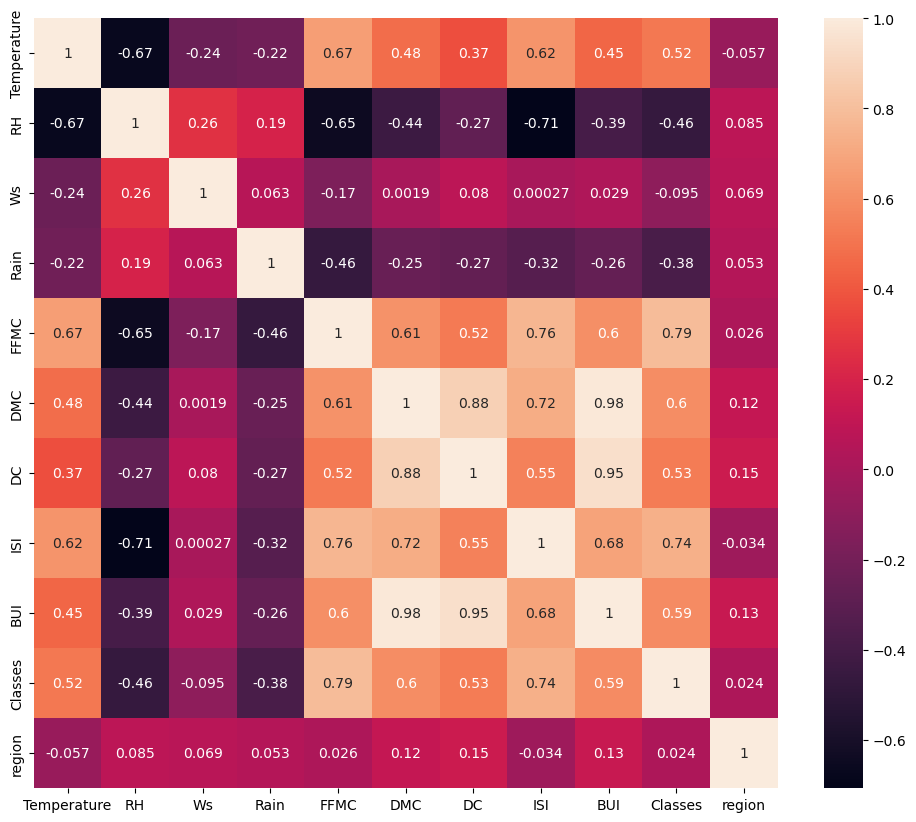

In [21]:
##check for multi collinearity
plt.figure(figsize=(12,10))
corr=x_train.corr()
sns.heatmap(corr,annot=True)

In [22]:
def correlation(dataset,threshold):
    col_corr=set()
    corr_matrix=dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i,j])>threshold:
                colname=corr_matrix.columns[i]
                col_corr.add(colname)
    return col_corr
            

In [26]:
#threshold set by the domain expert

extra_col=correlation(x_train,0.85)
extra_col

{'BUI', 'DC'}

In [27]:
from sklearn.metrics._scorer import completeness_scorer
##drop the features when correlation is more than 0.85
x_train.drop(extra_col,axis=1,inplace=True)
x_test.drop(extra_col,axis=1,inplace=True)
x_train.shape,x_test.shape

((182, 9), (61, 9))

#feature scaling


In [28]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.fit_transform(x_test)

x_train_scaled

array([[ 0.20934086,  0.20378905, -0.14327741, ..., -0.46967076,
         0.87577982, -0.98907071],
       [-1.79592422,  1.27496904,  2.02976333, ..., -1.04837933,
        -1.14183951,  1.01105006],
       [ 1.35520662, -0.46569844, -0.14327741, ...,  0.85653638,
         0.87577982,  1.01105006],
       ...,
       [ 2.21460594, -1.87162218, -0.50545087, ...,  2.18274351,
         0.87577982, -0.98907071],
       [ 0.78227374,  0.06989155, -0.50545087, ..., -0.73491219,
        -1.14183951,  1.01105006],
       [ 0.4958073 , -0.2648522 , -0.86762433, ..., -0.63846076,
        -1.14183951, -0.98907071]], shape=(182, 9))

Text(0.5, 1.0, 'x_train after scaling')

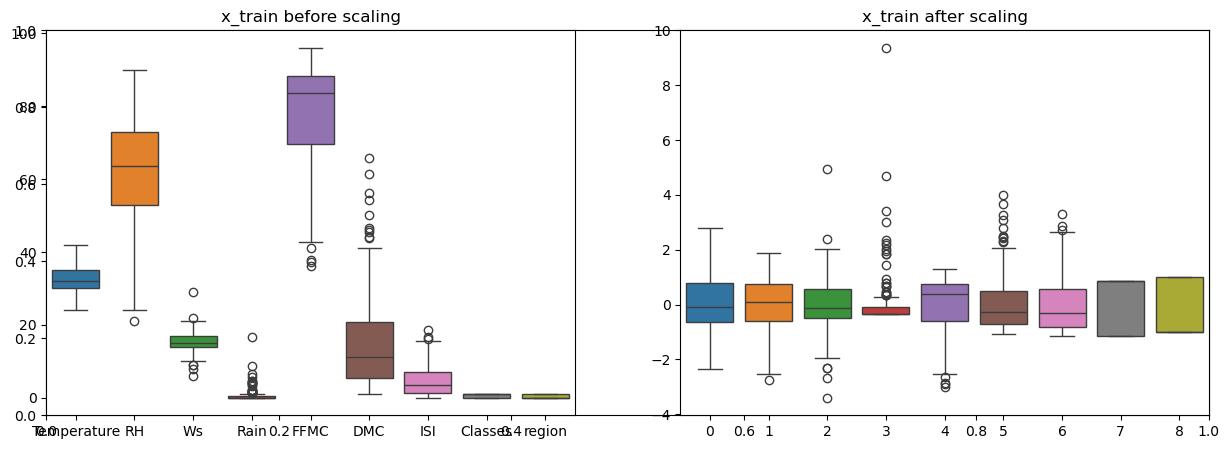

In [29]:
##box plots to umderstand effwct of standard scalar
plt.subplots(figsize=(15,5))
plt.subplot(1,2,1)
sns.boxplot(data=x_train)
plt.title('x_train before scaling')
plt.subplot(1,2,2)
sns.boxplot(data=x_train_scaled)
plt.title('x_train after scaling')

LINEAR REGRESSION MODEL

mean absolute error 1.147499816634259
r2 score 0.8629051715342554


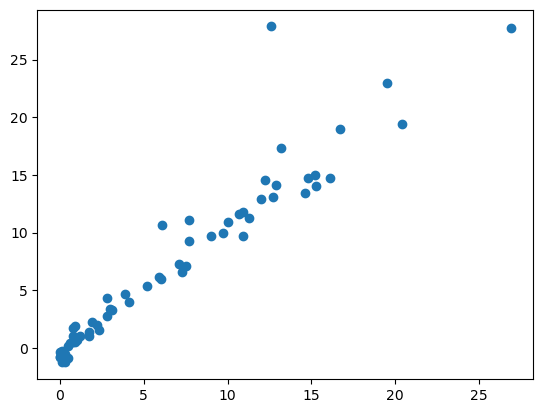

In [30]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,r2_score

linreg=LinearRegression()
linreg.fit(x_train_scaled,y_train)

y_pred=linreg.predict(x_test_scaled)
mae=mean_absolute_error(y_test,y_pred)

score=r2_score(y_test,y_pred)

print("mean absolute error",mae)
print("r2 score",score)

plt.scatter(y_test,y_pred)

#lasso regrression

mean absolute error 1.2499385448137836
r2 score 0.9018209329237022


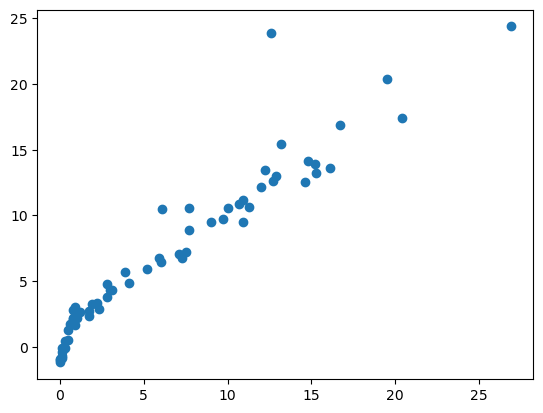

In [31]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error,r2_score

lasso=Lasso()
lasso.fit(x_train_scaled,y_train)

y_pred=lasso.predict(x_test_scaled)
mae=mean_absolute_error(y_test,y_pred)

score=r2_score(y_test,y_pred)

print("mean absolute error",mae)
print("r2 score",score)

plt.scatter(y_test,y_pred)

In [32]:
from sklearn.linear_model import LassoCV
lassocv=LassoCV(cv=5)
lassocv.fit(x_train_scaled,y_train)

,eps,0.001
,n_alphas,'deprecated'
,alphas,'warn'
,fit_intercept,True
,precompute,'auto'
,max_iter,1000
,tol,0.0001
,copy_X,True
,cv,5
,verbose,False
,n_jobs,None


In [33]:

lassocv. alpha_

np.float64(0.03381786052243767)

In [34]:
lassocv. alphas_

array([7.28583719, 6.79479614, 6.33684963, 5.90976717, 5.51146864,
       5.1400141 , 4.79359435, 4.47052214, 4.16922391, 3.88823217,
       3.62617834, 3.38178605, 3.15386499, 2.94130505, 2.74307093,
       2.55819713, 2.38578321, 2.2249894 , 2.07503256, 1.93518231,
       1.8047575 , 1.68312289, 1.56968604, 1.46389445, 1.36523287,
       1.27322074, 1.18740992, 1.10738247, 1.0327486 , 0.9631448 ,
       0.89823206, 0.83769423, 0.78123644, 0.72858372, 0.67947961,
       0.63368496, 0.59097672, 0.55114686, 0.51400141, 0.47935944,
       0.44705221, 0.41692239, 0.38882322, 0.36261783, 0.33817861,
       0.3153865 , 0.2941305 , 0.27430709, 0.25581971, 0.23857832,
       0.22249894, 0.20750326, 0.19351823, 0.18047575, 0.16831229,
       0.1569686 , 0.14638945, 0.13652329, 0.12732207, 0.11874099,
       0.11073825, 0.10327486, 0.09631448, 0.08982321, 0.08376942,
       0.07812364, 0.07285837, 0.06794796, 0.0633685 , 0.05909767,
       0.05511469, 0.05140014, 0.04793594, 0.04470522, 0.04169

#RIDGE REGRESSION

mean absolute error 1.1544261835608534
r2 score 0.8659791133938919


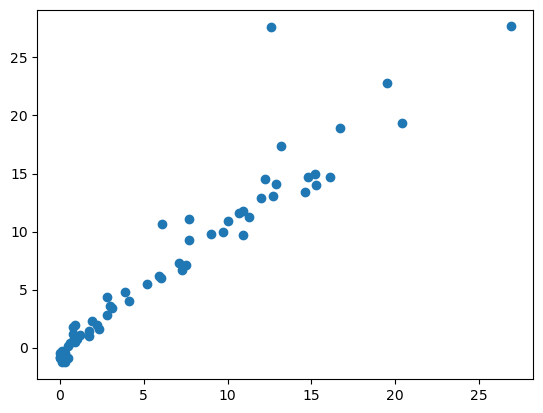

In [35]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error,r2_score

ridge=Ridge()
ridge.fit(x_train_scaled,y_train)
y_pred=ridge.predict(x_test_scaled)
mae=mean_absolute_error(y_test,y_pred)

score=r2_score(y_test,y_pred)

print("mean absolute error",mae)
print("r2 score",score)

plt.scatter(y_test,y_pred)

mean absolute error 1.6600739567004883
r2 score 0.8878285484066784


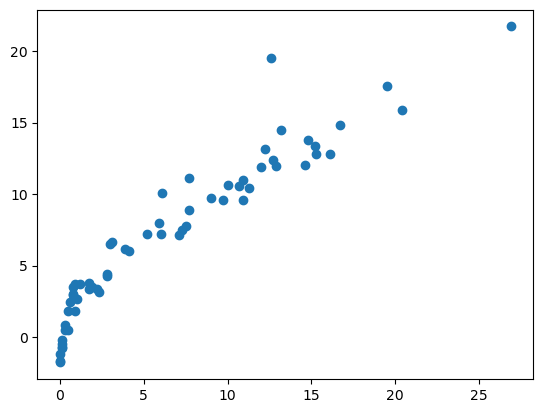

In [36]:
#elsticnet regression 

from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error,r2_score

elastic= ElasticNet()
elastic.fit(x_train_scaled,y_train)

y_pred=elastic.predict(x_test_scaled)
mae=mean_absolute_error(y_test,y_pred)

score=r2_score(y_test,y_pred)

print("mean absolute error",mae)
print("r2 score",score)

plt.scatter(y_test,y_pred)

mean absolute error 1.1573251238251436
r2 score 0.8679214144236918


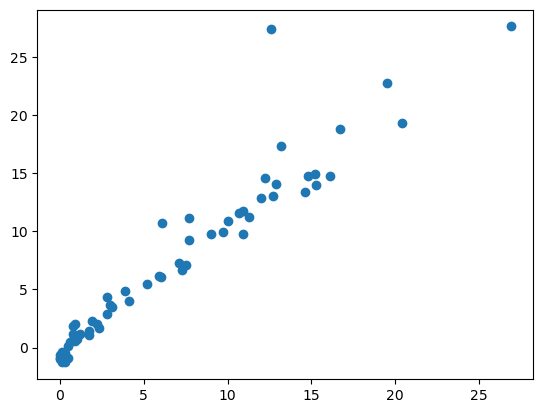

In [37]:
#elsticnet cv regression 

from sklearn.linear_model import ElasticNetCV
from sklearn.metrics import mean_absolute_error,r2_score

elasticcv= ElasticNetCV(cv=5)
elasticcv.fit(x_train_scaled,y_train)

y_pred=elasticcv.predict(x_test_scaled)
mae=mean_absolute_error(y_test,y_pred)

score=r2_score(y_test,y_pred)

print("mean absolute error",mae)
print("r2 score",score)

plt.scatter(y_test,y_pred)

# pickling the file

In [38]:
scaler

,copy,True
,with_mean,True
,with_std,True


In [39]:
elasticcv

,l1_ratio,0.5
,eps,0.001
,n_alphas,'deprecated'
,alphas,'warn'
,fit_intercept,True
,precompute,'auto'
,max_iter,1000
,tol,0.0001
,cv,5
,copy_X,True
,verbose,0


In [42]:
import pickle
pickle.dump(scaler, open(r'c:\Users\user\Downloads\ds practice\project\models\scaler.pkl', 'wb'))
pickle.dump(elasticcv, open(r'c:\Users\user\Downloads\ds practice\project\models\elasticcv.pkl', 'wb'))


In [ ]:
# 1. Date: (DD/MM/YYYY) Day, month (june' to 'september'), year (2012) Weather data observations
# 2. Temp: temperature noon (temperature max) in Celsius degrees: 22 to 42
# 3. RH: Relative Humidity in %: 21 to 90
# 4. Ws :Wind speed in km/h: 6 to 29
# 5. Rain: total day in mm: 0 to 16.8 FWI Components
# 6. Fine Fuel Moisture Code (FFMC) index from the FWI system: 28.6 to 92.5
# 7. Duff Moisture Code (DMC) index from the FWI system: 1.1 to 65.9
# 8. Drought Code (DC) index from the FWI system: 7 to 220.4
# 9. Initial Spread Index (ISI) index from the FWI system: 0 to 18.5
# 10. Buildup Index (BUI) index from the FWI system: 1.1 to 68
# 11. Fire Weather Index (FWI) Index: 0 to 31.1
# 12. Classes: two classes, namely Fire and not Fire